In [3]:
import os 
os.environ['CUDA_VISIBLE_DEVICES']="1"

In [ ]:
import torch 
import torch.nn as nn
import torch.nn.functional as F

import os

from tqdm import tqdm
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from CityScapes.datasets.progan_dataset import ProGanCityscapesDataset
from file_management import get_version_folder, save_config, load_config
from progan_model import Encoder,Generator, Discriminator, gradient_penalty

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
load_run = None

In [6]:
if load_run:
    config_path = os.path.join(load_run,'config.yaml')
    load_step = 5
    config = load_config(config_path)
    config['root_path'] = load_run

else:
    root = 'cache/progan'
    index_folder = get_version_folder(root)
    config = load_config('pro-gan.yaml')
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,'config.yaml')
    save_config(config, config_target_path)



Config saved to cache/progan/3/config.yaml


In [7]:

channels = config['channels']
# channels = [16] * len(channels)
sizes = [4 *(2**i) for i in range(len(channels))]
z_dim  = config['z_dim']
img_channels =3
batch_sizes = config['batch_sizes']
# assert len(batch_sizes) == len(sizes)

epochs = config['epochs']

enc_lr = config['enc_lr']
disc_lr= config['disc_lr']
gen_lr= config['gen_lr']
LAMBDA_GP  =config['LAMBDA_GP']
critic_mean_penalty = config['critic_mean_penalty']
alpha_start = config['alpha_start']


rec_loss = config['rec_loss']
enc_latent_loss = config['enc_latent_loss']

In [8]:



datasets = [ProGanCityscapesDataset(size=s) for s in sizes]
dataloaders = [DataLoader(d, batch_size=b_size, shuffle=True) for d,b_size in zip(datasets,batch_sizes)]


enc = Encoder(z_dim =z_dim,
                channels=channels,
                img_channels=img_channels).to(device)

gen = Generator(z_dim =z_dim,
                channels=channels,
                img_channels=img_channels).to(device)

disc = Discriminator(channels=channels,
                    img_channels=img_channels).to(device)

if load_run:
    assert load_step is not None
    enc.load_state_dict(torch.load(os.path.join(config["root_path"],str(load_step),"enc.pt")))
    gen.load_state_dict(torch.load(os.path.join(config["root_path"],str(load_step),"gen.pt")))
    disc.load_state_dict(torch.load(os.path.join(config["root_path"],str(load_step),"disc.pt")))

enc_optimizer = torch.optim.Adam(enc.parameters(), lr=enc_lr,betas=(0.0,0.99))
disc_optimizer = torch.optim.Adam(disc.parameters(), lr=disc_lr,betas=(0.0,0.99))
gen_optimizer = torch.optim.Adam(gen.parameters(), lr=gen_lr,betas=(0.0,0.99))

In [15]:
start_step = 6
alpha_start  =1
epochs = 40
for step in range(start_step,len(sizes)):
    step_path = os.path.join(config["root_path"],str(step))
    generated_images_path = os.path.join(step_path,'generated_images')
    os.makedirs(step_path, exist_ok=True)
    os.makedirs(generated_images_path, exist_ok=True)
    loader =dataloaders[step]
    alpha =  alpha_start
    for epoch in range(epochs):
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}, size={sizes[step]}")

        for batch_idx, real in enumerate(loop):
            real = real.to(device)
            cur_batch_size = real.shape[0]

            # train discriminator
            disc_optimizer.zero_grad()
            # Wrap in no_grad to save memory and avoid building unused graphs
            with torch.no_grad():
                encoder_latent_vector = enc(real, alpha, step)
                encoded_image = gen(encoder_latent_vector, alpha, step)

                noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)
                fake = gen(noise, alpha, step)

            disc_real = disc(real, alpha, step)
            disc_fake = disc(fake.detach(), alpha, step)
            disc_encoded = disc(encoded_image.detach(), alpha, step)

            gp_fake = gradient_penalty(disc, real, fake, alpha, step, device=device)
            gp_encoded = gradient_penalty(disc, real, encoded_image, alpha, step, device=device)

            loss_disc = (
                -(torch.mean(disc_real) - 0.5*(torch.mean(disc_fake)+torch.mean(disc_encoded)))
                + LAMBDA_GP * (gp_fake+gp_encoded)
                + (critic_mean_penalty * torch.mean(disc_real ** 2))
            )
        
            loss_disc.backward()
            disc_optimizer.step()


            # train generator and encoder
            gen_optimizer.zero_grad()        
            enc_optimizer.zero_grad()

            noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)
            fake = gen(noise, alpha, step)
            gen_fake_score = disc(fake, alpha, step)
            loss_gen_adv = -torch.mean(gen_fake_score) 

            encoder_latent_vector = enc(real, alpha, step)
            encoded_image = gen(encoder_latent_vector, alpha, step)
            encoded_fake_score = disc(encoded_image, alpha, step)

            loss_encoder_adv = - torch.mean(encoded_fake_score)


            # B. Reconstruction & Latent losses
            loss_recon = F.l1_loss(encoded_image, real)
            loss_latent = torch.mean(encoder_latent_vector ** 2)


            loss_enc =loss_encoder_adv+ enc_latent_loss * loss_latent + rec_loss * loss_recon
            # Combine losses into a single backward pass
            loss_gen_enc = loss_gen_adv + loss_enc
            
            loss_gen_enc.backward()
            # IMPORTANT: Step BOTH optimizers so the Generator learns to reconstruct!
            gen_optimizer.step()
            enc_optimizer.step()
           


            alpha = alpha + 2/(len(loader)*epochs)
            alpha = min(alpha, 1)

    
            loop.set_postfix(loss_gen=loss_gen_enc.item(), loss_disc=loss_disc.item(),alpha=alpha)

        with torch.no_grad():
            cur_batch_size  = 2
            noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)
            fake = gen(noise, alpha,step)
            batched_real  =real[:cur_batch_size]

            encoder_latent_vector = enc(batched_real, alpha, step)
            encoded_image = gen(encoder_latent_vector, alpha, step)


            row_titles = ["real", "Encoded",                                                                                        "  Generated"]

            fig,ax = plt.subplots(3,cur_batch_size)
            for i in range(cur_batch_size):
                ax[0][i].imshow((batched_real[i].detach().cpu().permute(1,2,0)+1)/2)
                ax[1][i].imshow((encoded_image[i].detach().cpu().permute(1,2,0)+1)/2)
                ax[2][i].imshow((fake[i].detach().cpu().permute(1,2,0)+1)/2)
                ax[0][i].set_title(row_titles[0])
                ax[1][i].set_title(row_titles[1])
                ax[2][i].set_title(row_titles[2])
            plt.savefig(os.path.join(generated_images_path,f"{epoch}.png"))                                                                                                                                                                                                                         
            plt.close()

        torch.save(gen.state_dict(), os.path.join(step_path,f"gen.pt"))
        torch.save(disc.state_dict(), os.path.join(step_path,f"disc.pt"))
        torch.save(enc.state_dict(), os.path.join(step_path, "enc.pt"))



Epoch 20/40, size=256:   5%|▌         | 273/5000 [02:57<51:12,  1.54it/s, alpha=1, loss_disc=-7.54, loss_gen=18.7]  


KeyboardInterrupt: 

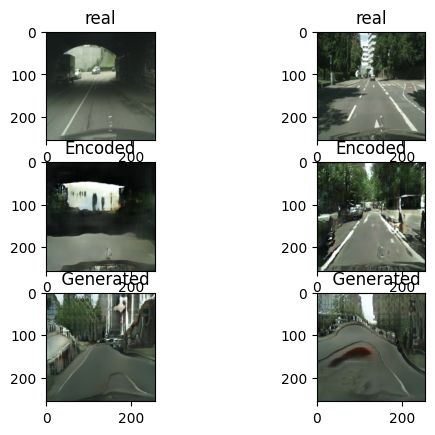

In [20]:
step = 6
real = next(iter(dataloaders[step])).to(device)
with torch.no_grad():

    cur_batch_size  = 2
    noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)
    fake = gen(noise, 1,step)
    batched_real  =real[:cur_batch_size]

    encoder_latent_vector = enc(batched_real, 1, step)
    encoded_image = gen(encoder_latent_vector, 1, step)


    row_titles = ["real", "Encoded", "  Generated"]

    fig,ax = plt.subplots(3,cur_batch_size)
    for i in range(cur_batch_size):
        ax[0][i].imshow((batched_real[i].detach().cpu().permute(1,2,0)+1)/2)
        ax[1][i].imshow((encoded_image[i].detach().cpu().permute(1,2,0)+1)/2)
        ax[2][i].imshow((fake[i].detach().cpu().permute(1,2,0)+1)/2)
        ax[0][i].set_title(row_titles[0])
        ax[1][i].set_title(row_titles[1])
        ax[2][i].set_title(row_titles[2])
    # plt.savefig(os.path.join(generated_images_path,f"{epoch}.png"))
    # plt.close()
